## 基础环境与路径设置

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import jax

# 【关键】把包含 'time_opt_erg_lib' 的父目录加入系统路径
# 假设你的 notebook 在 experiments/bias_search 目录下
# 你可能需要向上两级或三级找到 time_opt_erg_lib
# 请根据实际情况调整下面这一行：
sys.path.append('../../..') 
# 或者用绝对路径更保险：
sys.path.append('/home/songxy/code/time-optimal-ergodic-search')

# 验证一下是否能导入核心库
try:
    from time_opt_erg_lib.dynamics import DoubleIntegrator
    print("✅ 成功导入 time_opt_erg_lib")
except ImportError as e:
    print("❌ 导入失败，请检查 sys.path.append 的路径是否正确")
    print(e)

✅ 成功导入 time_opt_erg_lib


## RandomTargetDistribution (Cleaned / No ROS)

In [17]:
# ## Cell: RandomTargetDistribution (JAX/Numpy Namespace Fixed)

import jax.numpy as jnp   # 【关键】JAX数学库，用于自动求导和vmap
import numpy as np        # 【关键】标准Numpy，用于随机数生成和初始化
from jax import vmap
import matplotlib.pyplot as plt
import time

# --- 1. 定义父类 (TargetDistribution) ---
class TargetDistribution:
    def __init__(self, wrksp_bnds, grid_res=100):
        self.wrksp_bnds = wrksp_bnds
        self.grid_res = grid_res
        
        # 使用标准 numpy 生成坐标网格 (初始化时不需要梯度)
        x = np.linspace(wrksp_bnds[0][0], wrksp_bnds[0][1], grid_res)
        y = np.linspace(wrksp_bnds[1][0], wrksp_bnds[1][1], grid_res)
        self.X, self.Y = np.meshgrid(x, y)
        
        # 【关键】转为 jnp.stack，因为这个变量后面要喂给 JAX 的 vmap
        # [N*N, 2]
        self.grid_pts = jnp.stack([self.X.flatten(), self.Y.flatten()], axis=1)

    def p(self, x):
        """ 需要子类实现 """
        raise NotImplementedError

    @property
    def evals(self):
        """
        返回 (values, grid_pts) 元组
        values: [N*N] 扁平化 JAX 数组
        """
        # 1. 计算概率值 (使用 vmap 加速)
        # self.p 内部必须全用 jnp 操作
        vals = vmap(self.p)(self.grid_pts)
        
        # 2. 归一化
        vals = vals / jnp.sum(vals)
        
        # 3. 返回元组
        return (vals, self.grid_pts)

    @property
    def domain(self):
        return self.X, self.Y


# --- 2. 您的原始类 (修复了 np/jnp 混用问题) ---
class RandomTargetDistribution(TargetDistribution):
    def __init__(self, wrksp_bnds, n_gaussians=None, centers=None, covs=None, weights=None, seed=None):
        """
        创建随机或指定的高斯混合分布
        """
        # --- 初始化阶段使用标准 np ---
        if seed is not None:
            np.random.seed(seed)
        else:
            np.random.seed(int(time.time()))
        
        x_min, x_max = wrksp_bnds[0]
        y_min, y_max = wrksp_bnds[1]
        x_range = x_max - x_min
        y_range = y_max - y_min
        
        if n_gaussians is None:
            n_gaussians = np.random.randint(1, 8)
        
        if centers is None:
            centers = []
            min_distance = min(x_range, y_range) / 6
            
            for _ in range(n_gaussians):
                max_attempts = 50
                valid_point = False
                for _ in range(max_attempts):
                    candidate = [
                        np.random.uniform(x_min + 0.1*x_range, x_max - 0.1*x_range),
                        np.random.uniform(y_min + 0.1*y_range, y_max - 0.1*y_range)
                    ]
                    if not centers:
                        valid_point = True; break
                    
                    dists = [np.linalg.norm(np.array(candidate) - np.array(c)) for c in centers]
                    if min(dists) >= min_distance:
                        valid_point = True; break
                
                if valid_point: centers.append(candidate)
                else: centers.append(candidate) # fallback
                    
        if covs is None:
            covs = [np.random.uniform(8.0, 30.0) for _ in range(n_gaussians)]
        
        if weights is None:
            w = np.random.uniform(0.5, 1.5, size=n_gaussians)
            weights = w / sum(w)
        
        self.n_gaussians = n_gaussians
        self.centers = centers
        self.covs = covs
        self.weights = weights
        
        # 调用父类初始化
        super(RandomTargetDistribution, self).__init__(wrksp_bnds)
    
    def p(self, x):
        """
        【关键修复】所有数学运算必须使用 jnp (JAX Numpy)
        因为 x 是一个 JAX Tracer 对象
        """
        result = 0.0
        for i in range(self.n_gaussians):
            # 将 list 转为 jnp.array，然后与 tracer 计算
            diff = x[:2] - jnp.array(self.centers[i]) 
            exponent = -self.covs[i] * jnp.sum(diff**2) # 使用 jnp.sum
            result += self.weights[i] * jnp.exp(exponent) # 使用 jnp.exp
        return result
    
    def get_distribution_params(self):
        return {
            "n_gaussians": self.n_gaussians,
            "centers": self.centers,
            "covs": self.covs,
            "weights": self.weights
        }
    
    def visualize(self, title=None, save_path=None):
        fig, ax = plt.subplots(figsize=(10, 8))
        X, Y = self.domain
        # evals返回的是(vals, grid)，取vals并reshape
        # 注意：这里需要把 JAX array 转回 numpy 用于绘图，否则 matplotlib 可能会警告
        Z = np.array(self.evals[0]).reshape(X.shape) 
        
        contour = ax.contourf(X, Y, Z, levels=20, cmap='viridis')
        for i, center in enumerate(self.centers):
            ax.plot(center[0], center[1], 'ro', markersize=10)
            ax.text(center[0], center[1], f"{i+1}", color='white', 
                    fontsize=12, ha='center', va='center')
        
        if title: ax.set_title(title)
        else: ax.set_title(f"Random Distribution with {self.n_gaussians} Gaussians")
        
        plt.colorbar(contour, ax=ax)
        if save_path:
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            plt.close()
        else:
            plt.tight_layout()
            plt.show()
        return fig, ax

## build_solver_wild.py

In [15]:
# ## Build Solver Wild (Explicit JAX Fix)
import sys 
sys.path.append('../../..') 

import jax
import jax.numpy as jnp  # 【关键】显式命名为 jnp
from jax import vmap, jit
import numpy as np       # 标准 numpy 命名为 np

from time_opt_erg_lib.dynamics import DoubleIntegrator 
from time_opt_erg_lib.ergodic_metric import ErgodicMetric
from time_opt_erg_lib.fourier_utils import BasisFunc, get_phik, get_ck
from time_opt_erg_lib.opt_solver import AugmentedLagrangeSolver

def build_erg_time_opt_solver(args, target_distr):
    
    workspace_bnds = args['wrksp_bnds']

    # 1. 映射函数 (State -> Workspace [0,1])
    # 【关键修复】使用 jnp.stack 确保调用的是 JAX 操作
    def emap(x):
        val_x = (x[0]-workspace_bnds[0][0])/(workspace_bnds[0][1]-workspace_bnds[0][0])
        val_y = (x[1]-workspace_bnds[1][0])/(workspace_bnds[1][1]-workspace_bnds[1][0])
        return jnp.stack([val_x, val_y])  # <--- jnp.stack
            
    # 2. 初始化核心组件
    basis       = BasisFunc(n_basis=[8,8], emap=emap)
    erg_metric  = ErgodicMetric(basis)
    robot_model = DoubleIntegrator()
    n, m = robot_model.n, robot_model.m

    # 3. 计算目标分布的傅里叶系数
    # get_phik 内部会使用 JAX 操作，传入 JAX 数组是安全的
    args.update({
        'phik' : get_phik(target_distr.evals, basis),
    })

    # 4. 定义边界势场
    def barrier_cost(e):
        return (jnp.maximum(0, e-1) + jnp.maximum(0, -e))**2 # <--- jnp

    # 5. 定义 Loss
    # @jit
    def loss(params, args):
        x = params['x']
        tf = params['tf']
        e = vmap(emap)(x)
        return 100.*jnp.sum(barrier_cost(e)) + tf # <--- jnp

    # 6. 等式约束
    def eq_constr(params, args):
        x = params['x']
        u = params['u']
        x0 = args['x0']
        xf = args['xf']
        tf = params['tf']
        N = args['N']
        dt = tf/N
        return jnp.vstack([  # <--- jnp
            x[0] - x0, 
            x[1:,:]-(x[:-1,:]+dt*vmap(robot_model.dfdt)(x[:-1,:], u[:-1,:])),
            x[-1] - xf
        ])

    # 7. 不等式约束 (无避障)
    def ineq_constr(params, args):
        x = params['x']
        u = params['u']
        phik = args['phik']
        tf = params['tf']
        N = args['N']
        dt = tf/N
        
        ck = get_ck(x, basis, tf, dt)
        val_erg = erg_metric(ck, phik)
        
        _erg_ineq = [10. * jnp.array([val_erg - args['erg_ub'], -tf])] # <--- jnp
        _ctrl_box = [(jnp.abs(u) - 2.).flatten()] # <--- jnp
        
        return jnp.concatenate(_erg_ineq + _ctrl_box) # <--- jnp

    # 8. 初始化求解器
    # 初始猜测可以用标准 numpy 生成，反正传进去会被转
    x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = np.zeros((args['N'], robot_model.m))
    init_sol = {'x': x, 'u' : u, 'tf': np.array(15.0)} 
    
    solver = AugmentedLagrangeSolver(
                    init_sol,
                    loss, 
                    eq_constr, 
                    ineq_constr, 
                    args, 
                    step_size=1e-3,
                    c=1.0)
    
    return solver, []

## data_collection

### 固定自左下到右上

In [ ]:
# data_collection.py
import os
import json
import time
import datetime
import argparse
from tqdm import tqdm
import numpy as np
import jax.numpy as jnp
from jax.dlpack import to_dlpack
import matplotlib.pyplot as plt
# import numpy as onp


class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        # 处理JAX数组
        if isinstance(obj, jnp.ndarray):
            # 将JAX数组转换为NumPy数组
            return np.array(obj).tolist()
        # 处理NumPy数组和其他NumPy类型
        elif isinstance(obj, (np.ndarray, np.number)):
            return obj.tolist()
        # 处理其他NumPy类型
        elif isinstance(obj, (np.bool_, np.integer, np.floating, np.complexfloating)):
            return obj.item()
        return super(NumpyEncoder, self).default(obj)
    
class DataCollector:
    def __init__(self, output_dir, workspace_bounds=None,
                 randomize_start_end=False, min_separation=0.5,
                 start_margin=0.05, end_margin=None, max_attempts=1):
        """初始化数据采集器
        参数:
        - output_dir: 输出目录
        - workspace_bounds: 工作空间边界 [[x_min,x_max],[y_min,y_max]]
        - randomize_start_end: 是否随机化起点/终点
        - min_separation: 起终点最小欧氏距离(仅在随机化时生效)
        - start_margin/end_margin: 与边界保持的最小边距(比例, 相对于边界尺寸)
        - max_attempts: 求解失败时的最大重试次数(重新采样起终点)
        """
        self.output_dir = output_dir

        # 创建输出目录
        os.makedirs(output_dir, exist_ok=True)
        os.makedirs(os.path.join(output_dir, "distributions"), exist_ok=True)
        os.makedirs(os.path.join(output_dir, "trajectories"), exist_ok=True)
        os.makedirs(os.path.join(output_dir, "visualizations"), exist_ok=True)

        # 设置默认工作空间边界(如果未指定)
        if workspace_bounds is None:
            self.workspace_bounds = np.array([[0., 3.5], [-1., 3.5]])
        else:
            self.workspace_bounds = np.array(workspace_bounds)

        # 起终点随机化相关配置
        self.randomize_start_end = bool(randomize_start_end)
        self.min_separation = float(min_separation)
        self.start_margin = float(start_margin)
        self.end_margin = float(end_margin) if end_margin is not None else float(start_margin)
        self.max_attempts = int(max_attempts)

        # # 初始化ROS节点
        # try:
        #     rospy.init_node('ergodic_data_collector', anonymous=True)
        # except Exception as e:
        #     # 如果节点已经初始化或其他问题，记录错误但继续执行
        #     print(f"ROS initialization note: {e}")

        # 数据集索引
        self.dataset_index = {
            "created_at": datetime.datetime.now().isoformat(),
            "workspace_bounds": self.workspace_bounds.tolist(),
            "distributions": [],
            "trajectories": []
        }

    def generate_dataset(self, num_distributions=50, trajectories_per_distribution=20, 
                         gamma_range=(0.001, 0.5), visualize=True):
        """
        生成完整数据集
        
        参数:
        - num_distributions: 要生成的分布数量
        - trajectories_per_distribution: 每个分布生成的轨迹数量
        - gamma_range: γ值范围(最小值,最大值)
        - visualize: 是否生成可视化图像
        """
        print(f"Generating dataset with {num_distributions} distributions and {trajectories_per_distribution} trajectories per distribution")
        
        # 生成γ值列表 (对数均匀分布)
        gamma_values = np.exp(np.linspace(np.log(gamma_range[0]), np.log(gamma_range[1]), trajectories_per_distribution))
        
        # 生成分布
        for dist_idx in tqdm(range(num_distributions), desc="Generating distributions"):
            try:
                # 生成并处理每个分布
                self._process_distribution(dist_idx, gamma_values, visualize)
            except Exception as e:
                print(f"Error processing distribution {dist_idx}: {e}")
        
        # 保存数据集索引
        with open(os.path.join(self.output_dir, "dataset_index.json"), "w") as f:
            json.dump(self.dataset_index, f, indent=2, cls=NumpyEncoder)
        
        print(f"Dataset generation complete.")
        print(f"Generated {len(self.dataset_index['distributions'])} distributions")
        print(f"Generated {len(self.dataset_index['trajectories'])} trajectories")
        
        return self.dataset_index
    
    def _process_distribution(self, dist_idx, gamma_values, visualize):
        try:
            """处理单个分布的数据生成"""
            # 为每个分布生成随机种子
            dist_seed = int(time.time() * 1000) % 10000 + dist_idx
            
            # 创建随机分布
            distribution = RandomTargetDistribution(self.workspace_bounds, seed=dist_seed)
            dist_params = distribution.get_distribution_params()
            
            # 保存分布参数
            dist_id = f"dist_{dist_idx:04d}"
            dist_file = os.path.join(self.output_dir, "distributions", f"{dist_id}.json")
            with open(dist_file, "w") as f:
                json.dump({
                    "id": dist_id,
                    "params": dist_params,
                    "workspace_bounds": self.workspace_bounds
                }, f, indent=2, cls=NumpyEncoder)
            
            self.dataset_index["distributions"].append(dist_id)
            
            # 可视化分布
            if visualize:
                viz_path = os.path.join(self.output_dir, "visualizations", f"{dist_id}.png")
                distribution.visualize(title=f"Distribution {dist_id}", save_path=viz_path)
            
            # 为每个分布生成多个轨迹(不同γ值)
            successful_trajectories = 0
            for traj_idx, gamma in enumerate(gamma_values):
                if self._generate_trajectory(distribution, dist_id, traj_idx, gamma, visualize):
                    successful_trajectories += 1
            
            print(f"Generated {successful_trajectories}/{len(gamma_values)} trajectories for distribution {dist_id}")
        except Exception as e:
            import traceback
            print(f"Error processing distribution {dist_idx}: {e}")
            print(traceback.format_exc())
            return False
    
    def _generate_trajectory(self, distribution, dist_id, traj_idx, gamma, visualize):
        """生成单条轨迹"""
        try:
            # 采样起点与终点（可随机化）
            if self.randomize_start_end:
                xb, yb = self.workspace_bounds[0], self.workspace_bounds[1]
                dx, dy = xb[1] - xb[0], yb[1] - yb[0]
                sx_min, sx_max = xb[0] + self.start_margin * dx, xb[1] - self.start_margin * dx
                sy_min, sy_max = yb[0] + self.start_margin * dy, yb[1] - self.start_margin * dy
                ex_min, ex_max = xb[0] + self.end_margin * dx, xb[1] - self.end_margin * dx
                ey_min, ey_max = yb[0] + self.end_margin * dy, yb[1] - self.end_margin * dy
                # 简单重试以确保最小间距
                for _ in range(100):
                    start_pt = np.array([
                        np.random.uniform(sx_min, sx_max),
                        np.random.uniform(sy_min, sy_max)
                    ])
                    end_pt = np.array([
                        np.random.uniform(ex_min, ex_max),
                        np.random.uniform(ey_min, ey_max)
                    ])
                    if np.linalg.norm(end_pt - start_pt) >= self.min_separation:
                        break
                else:
                    # 退化情况：放宽约束
                    start_pt = np.array([sx_min, sy_min])
                    end_pt = np.array([ex_max, ey_max])
            else:
                start_pt = np.array([0.1, 0.1])
                end_pt = np.array([3.0, 3.0])

            x0 = np.array([start_pt[0], start_pt[1], 0., 0.])
            xf = np.array([end_pt[0], end_pt[1], 0., 0.])

            # 设置参数
            args = {
                'N': 100,
                'x0': x0,
                'xf': xf,
                'erg_ub': gamma,  # 使用gamma作为尔格迪克度量上限
                'alpha': 0.8,
                'wrksp_bnds': self.workspace_bounds
            }
            
            # 创建求解器
            solver, obstacles = build_erg_time_opt_solver(args, distribution)
            
            # 求解优化问题
            t_start = time.time()
            # 修改这里 - 使用正确的参数名称
            sol = solver.solve(max_iter=1000, eps=1e-5)
            
            # 检查解是否存在
            if sol is None:
                # 尝试从solver对象获取解
                if hasattr(solver, 'solution') and solver.solution is not None:
                    sol = solver.solution
                else:
                    print(f"Solver did not return a solution for dist={dist_id}, gamma={gamma}")
                    return False
            
            solve_time = time.time() - t_start
            
            # 获取结果
            # 如果sol是一个字典，直接访问其键
            if isinstance(sol, dict):
                states = sol['x']
                controls = sol['u']
                tf = float(sol['tf'])
            # 否则，尝试从solver对象获取解的组成部分
            else:
                # 假设solver.solution包含必要的键
                if hasattr(solver, 'solution') and solver.solution is not None:
                    states = solver.solution['x']
                    controls = solver.solution['u']
                    tf = float(solver.solution['tf']) if 'tf' in solver.solution else None
                else:
                    print(f"Cannot access solution data for dist={dist_id}, gamma={gamma}")
                    return False
            
            # 如果tf未定义，尝试从其他地方获取
            if tf is None and hasattr(solver, 'tf'):
                tf = float(solver.tf)
            elif tf is None:
                # 使用默认值或从参数计算
                print(f"Warning: Using default time for dist={dist_id}, gamma={gamma}")
                tf = 10.0  # 默认值，可以根据需要调整
            
            dt = tf / args['N']
            
            # 计算尔格迪克度量
            from time_opt_erg_lib.fourier_utils import BasisFunc, get_phik, get_ck
            from time_opt_erg_lib.ergodic_metric import ErgodicMetric
            
            basis = BasisFunc(n_basis=[8,8], emap=lambda x: jnp.array([
    (x[0]-self.workspace_bounds[0][0])/(self.workspace_bounds[0][1]-self.workspace_bounds[0][0]), 
    (x[1]-self.workspace_bounds[1][0])/(self.workspace_bounds[1][1]-self.workspace_bounds[1][0])]))
            phik = get_phik(distribution.evals, basis)
            ck = get_ck(states, basis, tf, dt)
            erg_metric = ErgodicMetric(basis)(ck, phik)
            
            # 构造轨迹结果（包含显式起点/终点）
            start_point = [float(start_pt[0]), float(start_pt[1])]
            end_point = [float(end_pt[0]), float(end_pt[1])]
            trajectory = {
                "states": states,
                "controls": controls,
                "time_step": dt,
                "total_time": tf,
                "ergodic_metric": float(erg_metric),
                "start_point": start_point,
                "end_point": end_point,
            }

            # 为轨迹创建唯一ID
            traj_id = f"{dist_id}_traj_{traj_idx:04d}_g{gamma:.6f}"

            # 确保目录存在
            os.makedirs(os.path.join(self.output_dir, "trajectories"), exist_ok=True)

            # 保存轨迹数据（向后兼容：下游读取仍可从states[0], states[-1]推断）
            traj_file = os.path.join(self.output_dir, "trajectories", f"{traj_id}.json")
            with open(traj_file, "w") as f:
                json.dump({
                    "id": traj_id,
                    "distribution_id": dist_id,
                    "gamma": float(gamma),
                    "states": states,
                    "controls": controls,
                    "time_step": float(dt),
                    "total_time": float(tf),
                    "ergodic_metric": float(erg_metric),
                    "solve_time": float(solve_time),
                    "start_point": start_point,
                    "end_point": end_point,
                }, f, indent=2, cls=NumpyEncoder)

            # 添加到索引
            self.dataset_index["trajectories"].append(traj_id)

            # 可视化轨迹
            if visualize:
                self._visualize_trajectory(distribution, trajectory, traj_id)

            print(f"Successfully generated trajectory {traj_id} with ergodic metric: {erg_metric}")
            return True
            
        except Exception as e:
            import traceback
            print(f"Error solving trajectory for dist={dist_id}, gamma={gamma}: {e}")
            print(traceback.format_exc())
            return False
    
    def _visualize_trajectory(self, distribution, trajectory, traj_id):
        """可视化轨迹"""
        try:
            # 创建图形
            fig, ax = plt.subplots(figsize=(10, 8))
            
            # 绘制分布
            X, Y = distribution.domain
            Z = distribution.evals[0].reshape(X.shape)
            contour = ax.contourf(X, Y, Z, levels=20, cmap='viridis', alpha=0.7)
            
            # 绘制轨迹
            states = np.array(trajectory["states"])
            ax.plot(states[:, 0], states[:, 1], 'r-', linewidth=2)
            
            # 标记起点和终点（优先使用显式字段）
            sp = trajectory.get("start_point")
            ep = trajectory.get("end_point")
            if sp is None:
                sp = states[0, :2]
            if ep is None:
                ep = states[-1, :2]
            ax.plot(sp[0], sp[1], 'go', markersize=8, label='Start')
            ax.plot(ep[0], ep[1], 'bo', markersize=8, label='End')

            # 添加信息
            gamma = float(trajectory["ergodic_metric"])
            total_time = float(trajectory["total_time"])
            ax.set_title(f"Trajectory {traj_id}\nErgodic Metric: {gamma:.6f}, Time: {total_time:.2f}s")

            # 保存图像
            viz_path = os.path.join(self.output_dir, "visualizations", f"{traj_id}.png")
            plt.savefig(viz_path, bbox_inches='tight', dpi=150)
            plt.close(fig)
        except Exception as e:
            print(f"Error visualizing trajectory {traj_id}: {e}")

# ## Cell: Run Data Collection (Main)

# 1. 定义参数 (替代 argparse)
OUTPUT_DIR = "data/ergodic_dataset_no_obs"   # 数据保存地址
NUM_DISTS = 10                 # 分布数量 (总量)
TRAJS_PER_DIST = 5             # 每个分布生成的轨迹数
VISUALIZE = False                # 是否生成可视化图 (跑大量数据建议 False)
GAMMA_RANGE = (0.005, 0.05)      # 【关键】低 Gamma 逼出 S 型轨迹

# 2. 实例化采集器
# 注意：这里 workspace_bounds 使用默认值 [[0, 3.5], [-1, 3.5]]
collector = DataCollector(output_dir=OUTPUT_DIR)

print(f"🚀 开始采集数据...")
print(f"📂 保存路径: {os.path.abspath(OUTPUT_DIR)}")
print(f"📊 计划总量: {NUM_DISTS} 个分布 x {TRAJS_PER_DIST} 条轨迹 = {NUM_DISTS * TRAJS_PER_DIST} 条数据")

# 3. 开始运行
# 注意：这里调用的是我们修改过的 generate_dataset，确保它传入了 gamma_range
collector.generate_dataset(
    num_distributions=NUM_DISTS,
    trajectories_per_distribution=TRAJS_PER_DIST,
    gamma_range=GAMMA_RANGE, 
    visualize=VISUALIZE
)

print("✅ 数据采集完成！")

🚀 开始采集全量数据 (随机起终点)...
📊 总量: 200 条
Generating dataset with 50 distributions and 4 trajectories per distribution


unsuccessful, tol:  0.19065857
Successfully generated trajectory dist_0000_traj_0000_g0.005000 with ergodic metric: 0.06704291701316833
unsuccessful, tol:  0.17910767
Successfully generated trajectory dist_0000_traj_0001_g0.010772 with ergodic metric: 0.11577104032039642
unsuccessful, tol:  0.35331726
Successfully generated trajectory dist_0000_traj_0002_g0.023208 with ergodic metric: 0.1920941174030304


unsuccessful, tol:  0.026778221
Successfully generated trajectory dist_0000_traj_0003_g0.050000 with ergodic metric: 0.03382238745689392
Generated 4/4 trajectories for distribution dist_0000
unsuccessful, tol:  0.14741516
Successfully generated trajectory dist_0001_traj_0000_g0.005000 with ergodic metric: 0.11019942164421082
unsuccessful, tol:  0.108169556
Successfully generated trajectory dist_0001_traj_0001_g0.010772 with ergodic metric: 0.07670095562934875
unsuccessful, tol:  0.5023346
Successfully generated trajectory dist_0001_traj_0002_g0.023208 with ergodic metric: 0.16024301946163177


unsuccessful, tol:  0.009141445
Successfully generated trajectory dist_0001_traj_0003_g0.050000 with ergodic metric: 0.04004989191889763
Generated 4/4 trajectories for distribution dist_0001
unsuccessful, tol:  0.48434448
Successfully generated trajectory dist_0002_traj_0000_g0.005000 with ergodic metric: 0.30866539478302
unsuccessful, tol:  0.046455383
Successfully generated trajectory dist_0002_traj_0001_g0.010772 with ergodic metric: 0.014845427125692368
unsuccessful, tol:  0.3604126
Successfully generated trajectory dist_0002_traj_0002_g0.023208 with ergodic metric: 0.18114398419857025


unsuccessful, tol:  0.011034012
Successfully generated trajectory dist_0002_traj_0003_g0.050000 with ergodic metric: 0.039771828800439835
Generated 4/4 trajectories for distribution dist_0002
unsuccessful, tol:  0.39987183
Successfully generated trajectory dist_0003_traj_0000_g0.005000 with ergodic metric: 0.3260262608528137
unsuccessful, tol:  0.143013
Successfully generated trajectory dist_0003_traj_0001_g0.010772 with ergodic metric: 0.08739519119262695
unsuccessful, tol:  0.10915375
Successfully generated trajectory dist_0003_traj_0002_g0.023208 with ergodic metric: 0.09848475456237793


...

unsuccessful, tol:  0.14519835
Successfully generated trajectory dist_0047_traj_0003_g0.050000 with ergodic metric: 0.02766992151737213
Generated 4/4 trajectories for distribution dist_0047
unsuccessful, tol:  0.15817642
Successfully generated trajectory dist_0048_traj_0000_g0.005000 with ergodic metric: 0.02836735174059868
unsuccessful, tol:  0.34458923
Successfully generated trajectory dist_0048_traj_0001_g0.010772 with ergodic metric: 0.1183246523141861
unsuccessful, tol:  0.48809814
Successfully generated trajectory dist_0048_traj_0002_g0.023208 with ergodic metric: 0.3635712265968323


unsuccessful, tol:  0.4705658
Successfully generated trajectory dist_0048_traj_0003_g0.050000 with ergodic metric: 0.25194036960601807
Generated 4/4 trajectories for distribution dist_0048
unsuccessful, tol:  0.0075626373
Successfully generated trajectory dist_0049_traj_0000_g0.005000 with ergodic metric: 0.005759911611676216
unsuccessful, tol:  0.9239502
Successfully generated trajectory dist_0049_traj_0001_g0.010772 with ergodic metric: 0.9563277959823608
unsuccessful, tol:  0.9939575
Successfully generated trajectory dist_0049_traj_0002_g0.023208 with ergodic metric: 0.5287971496582031


Generating distributions: 100%|██████████| 50/50 [03:56<00:00,  4.72s/it]

unsuccessful, tol:  0.2433052
Successfully generated trajectory dist_0049_traj_0003_g0.050000 with ergodic metric: 0.05628572776913643
Generated 4/4 trajectories for distribution dist_0049
Dataset generation complete.
Generated 50 distributions
Generated 200 trajectories


{'created_at': '2026-01-09T16:24:35.672153',
 'workspace_bounds': [[0.0, 3.5], [-1.0, 3.5]],
 'distributions': ['dist_0000',
  'dist_0001',
  'dist_0002',
  'dist_0003',
  'dist_0004',
  'dist_0005',
  'dist_0006',
  'dist_0007',
  'dist_0008',
  'dist_0009',
  'dist_0010',
  'dist_0011',
  'dist_0012',
  'dist_0013',
  'dist_0014',
  'dist_0015',
  'dist_0016',
  'dist_0017',
  'dist_0018',
  'dist_0019',
  'dist_0020',
  'dist_0021',
  'dist_0022',
  'dist_0023',
  'dist_0024',
  'dist_0025',
  'dist_0026',
  'dist_0027',
  'dist_0028',
  'dist_0029',
  'dist_0030',
  'dist_0031',
  'dist_0032',
  'dist_0033',
  'dist_0034',
  'dist_0035',
  'dist_0036',
  'dist_0037',
  'dist_0038',
  'dist_0039',
  'dist_0040',
  'dist_0041',
  'dist_0042',
  'dist_0043',
  'dist_0044',
  'dist_0045',
  'dist_0046',
  'dist_0047',
  'dist_0048',
  'dist_0049'],
 'trajectories': ['dist_0000_traj_0000_g0.005000',
  'dist_0000_traj_0001_g0.010772',
  'dist_0000_traj_0002_g0.023208',
  'dist_0000_traj_

### ergodic_dataset_wild_full-随机起终点

In [27]:
# data_collection.py
import os
import json
import time
import datetime
import argparse
from tqdm import tqdm
import numpy as np
import jax.numpy as jnp
from jax.dlpack import to_dlpack
import matplotlib.pyplot as plt
# import numpy as onp


class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        # 处理JAX数组
        if isinstance(obj, jnp.ndarray):
            # 将JAX数组转换为NumPy数组
            return np.array(obj).tolist()
        # 处理NumPy数组和其他NumPy类型
        elif isinstance(obj, (np.ndarray, np.number)):
            return obj.tolist()
        # 处理其他NumPy类型
        elif isinstance(obj, (np.bool_, np.integer, np.floating, np.complexfloating)):
            return obj.item()
        return super(NumpyEncoder, self).default(obj)
    
class DataCollector:
    def __init__(self, output_dir, workspace_bounds=None,
                 randomize_start_end=False, min_separation=0.5,
                 start_margin=0.05, end_margin=None, max_attempts=1):
        """初始化数据采集器
        参数:
        - output_dir: 输出目录
        - workspace_bounds: 工作空间边界 [[x_min,x_max],[y_min,y_max]]
        - randomize_start_end: 是否随机化起点/终点
        - min_separation: 起终点最小欧氏距离(仅在随机化时生效)
        - start_margin/end_margin: 与边界保持的最小边距(比例, 相对于边界尺寸)
        - max_attempts: 求解失败时的最大重试次数(重新采样起终点)
        """
        self.output_dir = output_dir

        # 创建输出目录
        os.makedirs(output_dir, exist_ok=True)
        os.makedirs(os.path.join(output_dir, "distributions"), exist_ok=True)
        os.makedirs(os.path.join(output_dir, "trajectories"), exist_ok=True)
        os.makedirs(os.path.join(output_dir, "visualizations"), exist_ok=True)

        # 设置默认工作空间边界(如果未指定)
        if workspace_bounds is None:
            self.workspace_bounds = np.array([[0., 3.5], [-1., 3.5]])
        else:
            self.workspace_bounds = np.array(workspace_bounds)

        # 起终点随机化相关配置
        self.randomize_start_end = bool(randomize_start_end)
        self.min_separation = float(min_separation)
        self.start_margin = float(start_margin)
        self.end_margin = float(end_margin) if end_margin is not None else float(start_margin)
        self.max_attempts = int(max_attempts)

        # # 初始化ROS节点
        # try:
        #     rospy.init_node('ergodic_data_collector', anonymous=True)
        # except Exception as e:
        #     # 如果节点已经初始化或其他问题，记录错误但继续执行
        #     print(f"ROS initialization note: {e}")

        # 数据集索引
        self.dataset_index = {
            "created_at": datetime.datetime.now().isoformat(),
            "workspace_bounds": self.workspace_bounds.tolist(),
            "distributions": [],
            "trajectories": []
        }

    def generate_dataset(self, num_distributions=50, trajectories_per_distribution=20, 
                         gamma_range=(0.001, 0.5), visualize=True):
        """
        生成完整数据集
        
        参数:
        - num_distributions: 要生成的分布数量
        - trajectories_per_distribution: 每个分布生成的轨迹数量
        - gamma_range: γ值范围(最小值,最大值)
        - visualize: 是否生成可视化图像
        """
        print(f"Generating dataset with {num_distributions} distributions and {trajectories_per_distribution} trajectories per distribution")
        
        # 生成γ值列表 (对数均匀分布)
        gamma_values = np.exp(np.linspace(np.log(gamma_range[0]), np.log(gamma_range[1]), trajectories_per_distribution))
        
        # 生成分布
        for dist_idx in tqdm(range(num_distributions), desc="Generating distributions"):
            try:
                # 生成并处理每个分布
                self._process_distribution(dist_idx, gamma_values, visualize)
            except Exception as e:
                print(f"Error processing distribution {dist_idx}: {e}")
        
        # 保存数据集索引
        with open(os.path.join(self.output_dir, "dataset_index.json"), "w") as f:
            json.dump(self.dataset_index, f, indent=2, cls=NumpyEncoder)
        
        print(f"Dataset generation complete.")
        print(f"Generated {len(self.dataset_index['distributions'])} distributions")
        print(f"Generated {len(self.dataset_index['trajectories'])} trajectories")
        
        return self.dataset_index
    
    def _process_distribution(self, dist_idx, gamma_values, visualize):
        try:
            """处理单个分布的数据生成"""
            # 为每个分布生成随机种子
            dist_seed = int(time.time() * 1000) % 10000 + dist_idx
            
            # 创建随机分布
            distribution = RandomTargetDistribution(self.workspace_bounds, seed=dist_seed)
            dist_params = distribution.get_distribution_params()
            
            # 保存分布参数
            dist_id = f"dist_{dist_idx:04d}"
            dist_file = os.path.join(self.output_dir, "distributions", f"{dist_id}.json")
            with open(dist_file, "w") as f:
                json.dump({
                    "id": dist_id,
                    "params": dist_params,
                    "workspace_bounds": self.workspace_bounds
                }, f, indent=2, cls=NumpyEncoder)
            
            self.dataset_index["distributions"].append(dist_id)
            
            # 可视化分布
            if visualize:
                viz_path = os.path.join(self.output_dir, "visualizations", f"{dist_id}.png")
                distribution.visualize(title=f"Distribution {dist_id}", save_path=viz_path)
            
            # 为每个分布生成多个轨迹(不同γ值)
            successful_trajectories = 0
            for traj_idx, gamma in enumerate(gamma_values):
                if self._generate_trajectory(distribution, dist_id, traj_idx, gamma, visualize):
                    successful_trajectories += 1
            
            print(f"Generated {successful_trajectories}/{len(gamma_values)} trajectories for distribution {dist_id}")
        except Exception as e:
            import traceback
            print(f"Error processing distribution {dist_idx}: {e}")
            print(traceback.format_exc())
            return False
    
    def _generate_trajectory(self, distribution, dist_id, traj_idx, gamma, visualize):
        """生成单条轨迹"""
        try:
            # 采样起点与终点（可随机化）
            if self.randomize_start_end:
                xb, yb = self.workspace_bounds[0], self.workspace_bounds[1]
                dx, dy = xb[1] - xb[0], yb[1] - yb[0]
                sx_min, sx_max = xb[0] + self.start_margin * dx, xb[1] - self.start_margin * dx
                sy_min, sy_max = yb[0] + self.start_margin * dy, yb[1] - self.start_margin * dy
                ex_min, ex_max = xb[0] + self.end_margin * dx, xb[1] - self.end_margin * dx
                ey_min, ey_max = yb[0] + self.end_margin * dy, yb[1] - self.end_margin * dy
                # 简单重试以确保最小间距
                for _ in range(100):
                    start_pt = np.array([
                        np.random.uniform(sx_min, sx_max),
                        np.random.uniform(sy_min, sy_max)
                    ])
                    end_pt = np.array([
                        np.random.uniform(ex_min, ex_max),
                        np.random.uniform(ey_min, ey_max)
                    ])
                    if np.linalg.norm(end_pt - start_pt) >= self.min_separation:
                        break
                else:
                    # 退化情况：放宽约束
                    start_pt = np.array([sx_min, sy_min])
                    end_pt = np.array([ex_max, ey_max])
            else:
                start_pt = np.array([0.1, 0.1])
                end_pt = np.array([3.0, 3.0])

            x0 = np.array([start_pt[0], start_pt[1], 0., 0.])
            xf = np.array([end_pt[0], end_pt[1], 0., 0.])

            # 设置参数
            args = {
                'N': 100,
                'x0': x0,
                'xf': xf,
                'erg_ub': gamma,  # 使用gamma作为尔格迪克度量上限
                'alpha': 0.8,
                'wrksp_bnds': self.workspace_bounds
            }
            
            # 创建求解器
            solver, obstacles = build_erg_time_opt_solver(args, distribution)
            
            # 求解优化问题
            t_start = time.time()
            # 修改这里 - 使用正确的参数名称
            sol = solver.solve(max_iter=1000, eps=1e-5)
            
            # 检查解是否存在
            if sol is None:
                # 尝试从solver对象获取解
                if hasattr(solver, 'solution') and solver.solution is not None:
                    sol = solver.solution
                else:
                    print(f"Solver did not return a solution for dist={dist_id}, gamma={gamma}")
                    return False
            
            solve_time = time.time() - t_start
            
            # 获取结果
            # 如果sol是一个字典，直接访问其键
            if isinstance(sol, dict):
                states = sol['x']
                controls = sol['u']
                tf = float(sol['tf'])
            # 否则，尝试从solver对象获取解的组成部分
            else:
                # 假设solver.solution包含必要的键
                if hasattr(solver, 'solution') and solver.solution is not None:
                    states = solver.solution['x']
                    controls = solver.solution['u']
                    tf = float(solver.solution['tf']) if 'tf' in solver.solution else None
                else:
                    print(f"Cannot access solution data for dist={dist_id}, gamma={gamma}")
                    return False
            
            # 如果tf未定义，尝试从其他地方获取
            if tf is None and hasattr(solver, 'tf'):
                tf = float(solver.tf)
            elif tf is None:
                # 使用默认值或从参数计算
                print(f"Warning: Using default time for dist={dist_id}, gamma={gamma}")
                tf = 10.0  # 默认值，可以根据需要调整
            
            dt = tf / args['N']
            
            # 计算尔格迪克度量
            from time_opt_erg_lib.fourier_utils import BasisFunc, get_phik, get_ck
            from time_opt_erg_lib.ergodic_metric import ErgodicMetric
            
            basis = BasisFunc(n_basis=[8,8], emap=lambda x: jnp.array([
    (x[0]-self.workspace_bounds[0][0])/(self.workspace_bounds[0][1]-self.workspace_bounds[0][0]), 
    (x[1]-self.workspace_bounds[1][0])/(self.workspace_bounds[1][1]-self.workspace_bounds[1][0])]))
            phik = get_phik(distribution.evals, basis)
            ck = get_ck(states, basis, tf, dt)
            erg_metric = ErgodicMetric(basis)(ck, phik)
            
            # 构造轨迹结果（包含显式起点/终点）
            start_point = [float(start_pt[0]), float(start_pt[1])]
            end_point = [float(end_pt[0]), float(end_pt[1])]
            trajectory = {
                "states": states,
                "controls": controls,
                "time_step": dt,
                "total_time": tf,
                "ergodic_metric": float(erg_metric),
                "start_point": start_point,
                "end_point": end_point,
            }

            # 为轨迹创建唯一ID
            traj_id = f"{dist_id}_traj_{traj_idx:04d}_g{gamma:.6f}"

            # 确保目录存在
            os.makedirs(os.path.join(self.output_dir, "trajectories"), exist_ok=True)

            # 保存轨迹数据（向后兼容：下游读取仍可从states[0], states[-1]推断）
            traj_file = os.path.join(self.output_dir, "trajectories", f"{traj_id}.json")
            with open(traj_file, "w") as f:
                json.dump({
                    "id": traj_id,
                    "distribution_id": dist_id,
                    "gamma": float(gamma),
                    "states": states,
                    "controls": controls,
                    "time_step": float(dt),
                    "total_time": float(tf),
                    "ergodic_metric": float(erg_metric),
                    "solve_time": float(solve_time),
                    "start_point": start_point,
                    "end_point": end_point,
                }, f, indent=2, cls=NumpyEncoder)

            # 添加到索引
            self.dataset_index["trajectories"].append(traj_id)

            # 可视化轨迹
            if visualize:
                self._visualize_trajectory(distribution, trajectory, traj_id)

            print(f"Successfully generated trajectory {traj_id} with ergodic metric: {erg_metric}")
            return True
            
        except Exception as e:
            import traceback
            print(f"Error solving trajectory for dist={dist_id}, gamma={gamma}: {e}")
            print(traceback.format_exc())
            return False
    
    def _visualize_trajectory(self, distribution, trajectory, traj_id):
        """可视化轨迹"""
        try:
            # 创建图形
            fig, ax = plt.subplots(figsize=(10, 8))
            
            # 绘制分布
            X, Y = distribution.domain
            Z = distribution.evals[0].reshape(X.shape)
            contour = ax.contourf(X, Y, Z, levels=20, cmap='viridis', alpha=0.7)
            
            # 绘制轨迹
            states = np.array(trajectory["states"])
            ax.plot(states[:, 0], states[:, 1], 'r-', linewidth=2)
            
            # 标记起点和终点（优先使用显式字段）
            sp = trajectory.get("start_point")
            ep = trajectory.get("end_point")
            if sp is None:
                sp = states[0, :2]
            if ep is None:
                ep = states[-1, :2]
            ax.plot(sp[0], sp[1], 'go', markersize=8, label='Start')
            ax.plot(ep[0], ep[1], 'bo', markersize=8, label='End')

            # 添加信息
            gamma = float(trajectory["ergodic_metric"])
            total_time = float(trajectory["total_time"])
            ax.set_title(f"Trajectory {traj_id}\nErgodic Metric: {gamma:.6f}, Time: {total_time:.2f}s")

            # 保存图像
            viz_path = os.path.join(self.output_dir, "visualizations", f"{traj_id}.png")
            plt.savefig(viz_path, bbox_inches='tight', dpi=150)
            plt.close(fig)
        except Exception as e:
            print(f"Error visualizing trajectory {traj_id}: {e}")

# ## Cell: Run Data Collection (Main)

# ## Cell: Run Data Collection (Main) with Randomization

# 1. 配置参数
OUTPUT_DIR = "data/ergodic_dataset_wild_full" # 换个名字，别覆盖之前的
NUM_DISTS = 500         # 500 个分布
TRAJS_PER_DIST = 40     # 每个分布 40 条
VISUALIZE = False       # 跑大量数据关闭可视化
GAMMA_RANGE = (0.005, 0.05) 

# 2. 实例化采集器 - 【关键修改】开启随机化
collector = DataCollector(
    output_dir=OUTPUT_DIR,
    # 开启起终点随机化
    randomize_start_end=True, 
    # 最小间隔 1.5m，防止起点终点太近，那样生成的轨迹没意义
    min_separation=1.5,       
    # 留一点边距，别生成在地图边缘
    start_margin=0.1          
)

print(f"🚀 开始采集全量数据 (随机起终点)...")
print(f"📊 总量: {NUM_DISTS * TRAJS_PER_DIST} 条")

# 3. 运行
collector.generate_dataset(
    num_distributions=NUM_DISTS,
    trajectories_per_distribution=TRAJS_PER_DIST,
    gamma_range=GAMMA_RANGE, 
    visualize=VISUALIZE
)

🚀 开始采集全量数据 (随机起终点)...
📊 总量: 20000 条
Generating dataset with 500 distributions and 40 trajectories per distribution


Generating distributions:   0%|          | 0/500 [00:00<?, ?it/s]

unsuccessful, tol:  0.43162537
Successfully generated trajectory dist_0000_traj_0000_g0.005000 with ergodic metric: 0.12700505554676056
unsuccessful, tol:  0.08753967
Successfully generated trajectory dist_0000_traj_0001_g0.005304 with ergodic metric: 0.07096138596534729
unsuccessful, tol:  1.0753784
Successfully generated trajectory dist_0000_traj_0002_g0.005627 with ergodic metric: 0.5852034687995911
unsuccessful, tol:  0.6538391
Successfully generated trajectory dist_0000_traj_0003_g0.005969 with ergodic metric: 0.14350198209285736
unsuccessful, tol:  0.5777588
Successfully generated trajectory dist_0000_traj_0004_g0.006332 with ergodic metric: 1.033185601234436
unsuccessful, tol:  0.70947266
Successfully generated trajectory dist_0000_traj_0005_g0.006717 with ergodic metric: 0.5106998085975647
unsuccessful, tol:  0.33407593
Successfully generated trajectory dist_0000_traj_0006_g0.007126 with ergodic metric: 0.04840724915266037
unsuccessful, tol:  0.46194458
Successfully generated t

Generating distributions:   0%|          | 1/500 [00:47<6:31:50, 47.12s/it]

unsuccessful, tol:  0.028182983
Successfully generated trajectory dist_0000_traj_0039_g0.050000 with ergodic metric: 0.10531032830476761
Generated 40/40 trajectories for distribution dist_0000
unsuccessful, tol:  0.3462143
Successfully generated trajectory dist_0001_traj_0000_g0.005000 with ergodic metric: 0.09831346571445465
unsuccessful, tol:  0.36741638
Successfully generated trajectory dist_0001_traj_0001_g0.005304 with ergodic metric: 0.18359220027923584
unsuccessful, tol:  0.16844559
Successfully generated trajectory dist_0001_traj_0002_g0.005627 with ergodic metric: 0.05414773151278496
unsuccessful, tol:  0.11290741
Successfully generated trajectory dist_0001_traj_0003_g0.005969 with ergodic metric: 0.07615715265274048
unsuccessful, tol:  0.19198608
Successfully generated trajectory dist_0001_traj_0004_g0.006332 with ergodic metric: 0.058465298265218735
unsuccessful, tol:  0.21178436
Successfully generated trajectory dist_0001_traj_0005_g0.006717 with ergodic metric: 0.081863440

...

Generating distributions: 100%|█████████▉| 499/500 [6:40:54<00:47, 47.20s/it]

unsuccessful, tol:  0.06277597
Successfully generated trajectory dist_0498_traj_0039_g0.050000 with ergodic metric: 0.0394672155380249
Generated 40/40 trajectories for distribution dist_0498
unsuccessful, tol:  0.46832275
Successfully generated trajectory dist_0499_traj_0000_g0.005000 with ergodic metric: 0.6555869579315186
unsuccessful, tol:  0.51794434
Successfully generated trajectory dist_0499_traj_0001_g0.005304 with ergodic metric: 0.4729713499546051
unsuccessful, tol:  0.6760559
Successfully generated trajectory dist_0499_traj_0002_g0.005627 with ergodic metric: 0.2442750334739685
unsuccessful, tol:  0.23120117
Successfully generated trajectory dist_0499_traj_0003_g0.005969 with ergodic metric: 0.7517045140266418
unsuccessful, tol:  0.3852234
Successfully generated trajectory dist_0499_traj_0004_g0.006332 with ergodic metric: 0.08346584439277649
unsuccessful, tol:  0.33784485
Successfully generated trajectory dist_0499_traj_0005_g0.006717 with ergodic metric: 0.07315317541360855

Generating distributions: 100%|██████████| 500/500 [6:41:41<00:00, 48.20s/it]

unsuccessful, tol:  0.025078297
Successfully generated trajectory dist_0499_traj_0039_g0.050000 with ergodic metric: 0.03373253345489502
Generated 40/40 trajectories for distribution dist_0499
Dataset generation complete.
Generated 500 distributions
Generated 20000 trajectories


{'created_at': '2026-01-09T17:36:24.303289',
 'workspace_bounds': [[0.0, 3.5], [-1.0, 3.5]],
 'distributions': ['dist_0000',
  'dist_0001',
  'dist_0002',
  'dist_0003',
  'dist_0004',
  'dist_0005',
  'dist_0006',
  'dist_0007',
  'dist_0008',
  'dist_0009',
  'dist_0010',
  'dist_0011',
  'dist_0012',
  'dist_0013',
  'dist_0014',
  'dist_0015',
  'dist_0016',
  'dist_0017',
  'dist_0018',
  'dist_0019',
  'dist_0020',
  'dist_0021',
  'dist_0022',
  'dist_0023',
  'dist_0024',
  'dist_0025',
  'dist_0026',
  'dist_0027',
  'dist_0028',
  'dist_0029',
  'dist_0030',
  'dist_0031',
  'dist_0032',
  'dist_0033',
  'dist_0034',
  'dist_0035',
  'dist_0036',
  'dist_0037',
  'dist_0038',
  'dist_0039',
  'dist_0040',
  'dist_0041',
  'dist_0042',
  'dist_0043',
  'dist_0044',
  'dist_0045',
  'dist_0046',
  'dist_0047',
  'dist_0048',
  'dist_0049',
  'dist_0050',
  'dist_0051',
  'dist_0052',
  'dist_0053',
  'dist_0054',
  'dist_0055',
  'dist_0056',
  'dist_0057',
  'dist_0058',
  'di

## Cell: Data Verification & Analytics (Full Version)

👁️ 正在可视化 9 个随机样本...


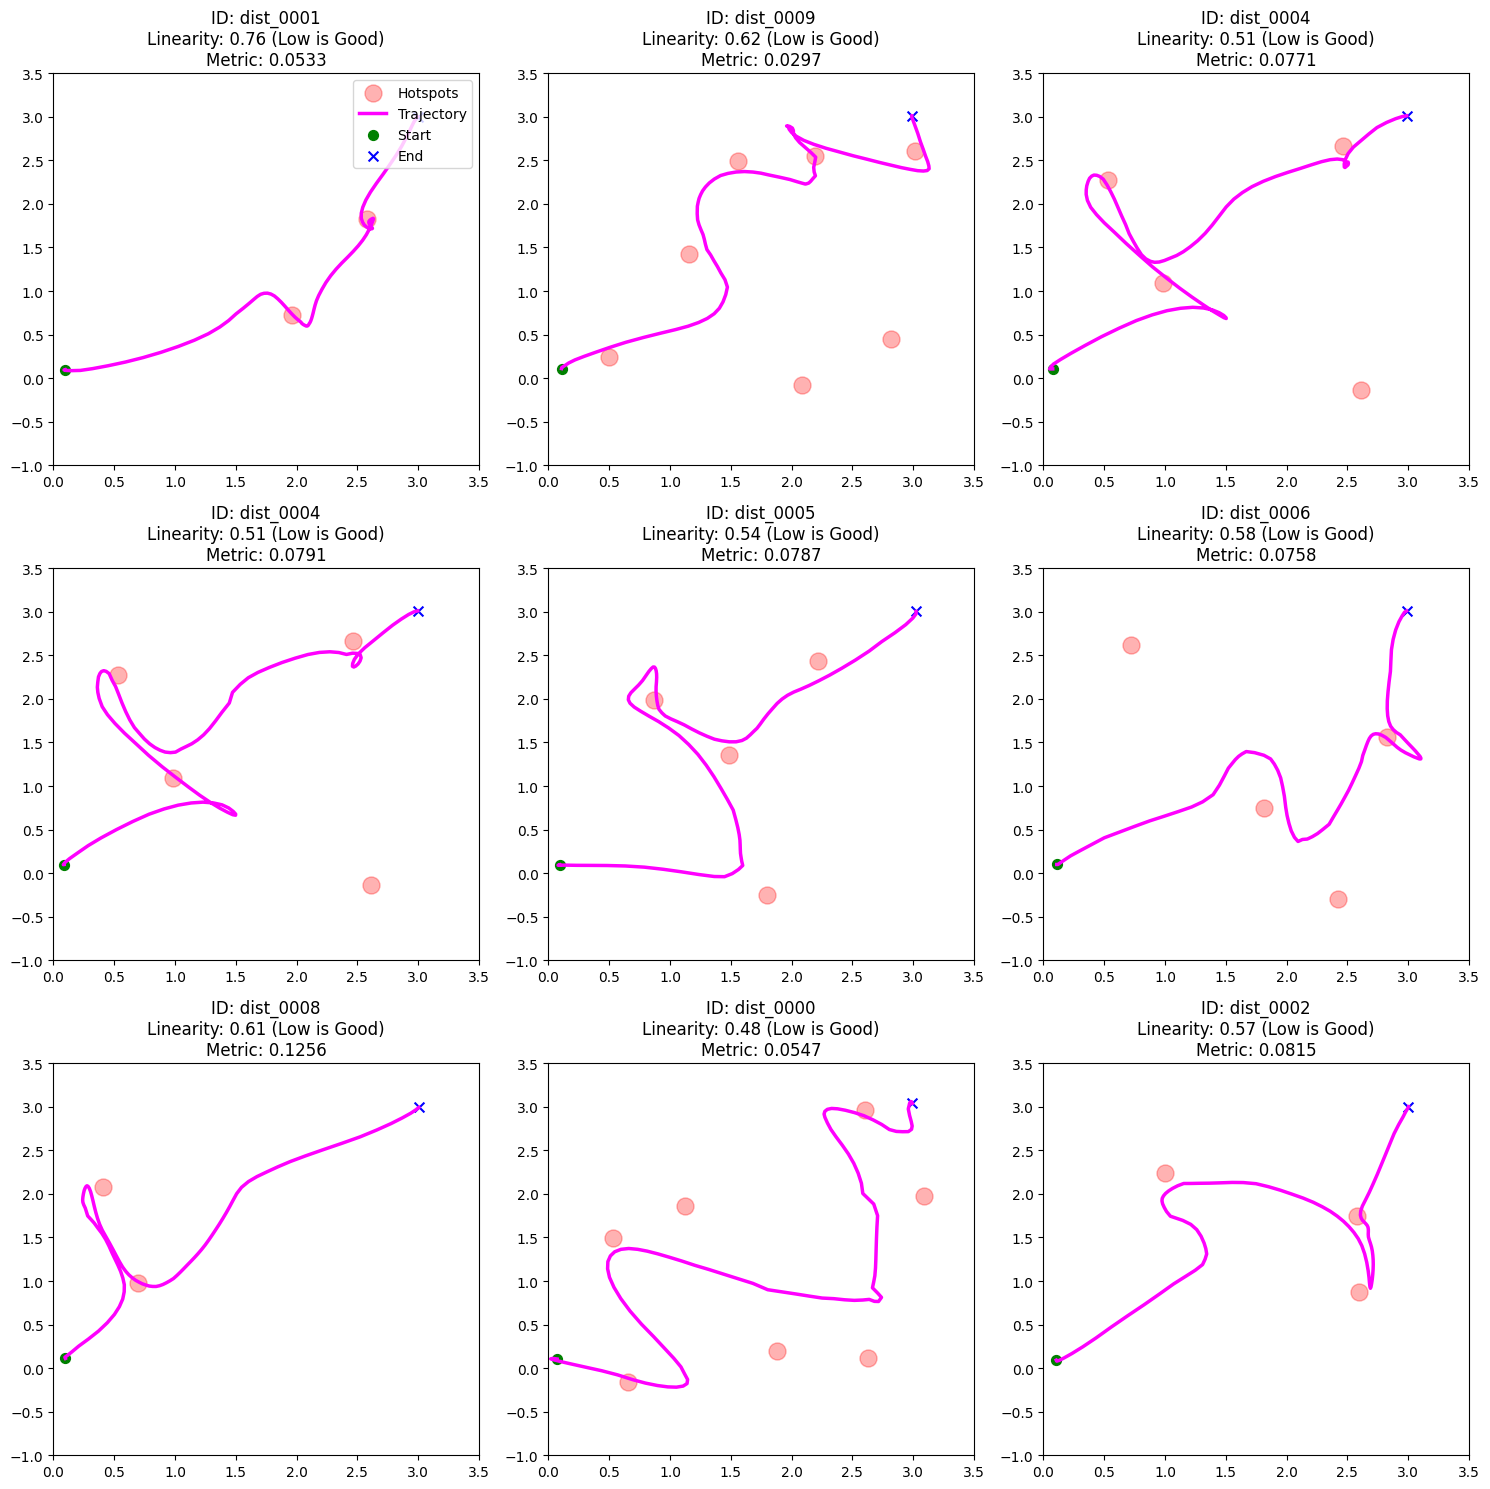

📊 正在分析前 50 / 50 条数据...


100%|█████████████████████████████████████████| 50/50 [00:00<00:00, 2822.81it/s]


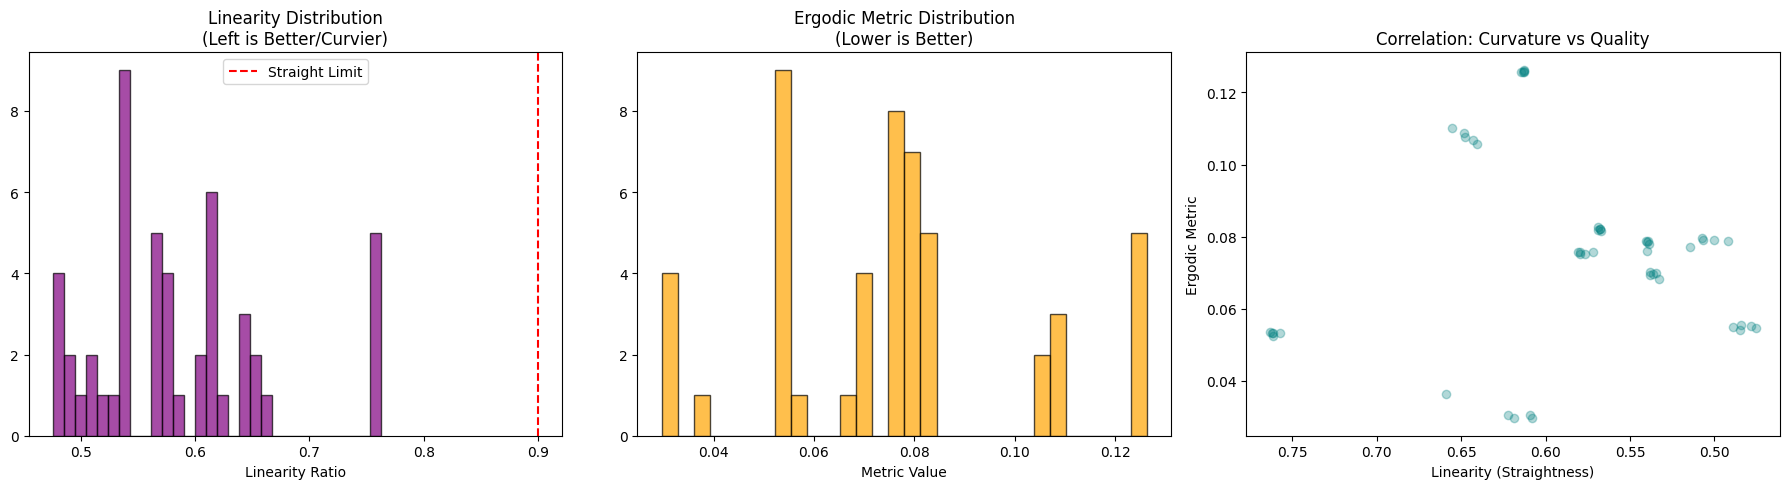


🏆 数据集质量总结:
   - 平均线性度 (Linearity): 0.5853 (越低越好)
   - 弯曲轨迹占比 (< 0.8):  100.0%
   - 平均 Ergodic Metric:   0.0757


In [ ]:
# ## Cell: Data Verification & Analytics (Full Version)
import os
import json
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
# 【关键修复】使用标准 tqdm，避免 ipywidgets 报错
from tqdm import tqdm 

# 配置：数据路径
DATASET_DIR = "/home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/data/ergodic_dataset_no_obs"
TRAJ_DIR = os.path.join(DATASET_DIR, "trajectories")
DIST_DIR = os.path.join(DATASET_DIR, "distributions")

# ==========================================
# 1. 辅助函数：计算轨迹的"弯曲度" (Linearity)
# ==========================================
def analyze_trajectory_geometry(states):
    """
    计算轨迹几何特征
    Linearity Ratio = 直线距离 / 实际路径长度
    - 接近 1.0 : 直线 (Bad for us)
    - 接近 0.5 : 强烈的 S 型或 U 型 (Good for us)
    """
    states = np.array(states)
    pos = states[:, :2]
    
    # 1. 欧氏距离 (起点到终点)
    start = pos[0]
    end = pos[-1]
    euclidean_dist = np.linalg.norm(end - start)
    
    # 2. 实际路径长度 (累加每一步)
    steps = np.linalg.norm(pos[1:] - pos[:-1], axis=1)
    path_length = np.sum(steps)
    
    # 3. 线性度 (越小越弯)
    if path_length < 1e-6: return 1.0 # 没动
    linearity = euclidean_dist / path_length
    
    return linearity, path_length, euclidean_dist

# ==========================================
# 2. 随机抽样可视化 (The Eye Test)
# ==========================================
def visualize_random_samples(num_samples=9):
    json_files = glob.glob(os.path.join(TRAJ_DIR, "*.json"))
    if not json_files:
        print("❌ 没有找到任何轨迹文件！请检查路径。")
        return

    # 随机采样
    samples = random.sample(json_files, min(num_samples, len(json_files)))
    
    # 创建画布
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()
    
    print(f"👁️ 正在可视化 {len(samples)} 个随机样本...")
    
    for i, traj_file in enumerate(samples):
        try:
            with open(traj_file, 'r') as f:
                data = json.load(f)
                
            # 加载对应的分布文件来画背景
            dist_id = data['distribution_id']
            dist_file = os.path.join(DIST_DIR, f"{dist_id}.json")
            
            ax = axes[i]
            
            # 1. 画分布 (如果有的话)
            if os.path.exists(dist_file):
                with open(dist_file, 'r') as f:
                    dist_data = json.load(f)
                    params = dist_data['params']
                    # 简易画法：只画中心点
                    centers = np.array(params['centers'])
                    ax.scatter(centers[:,0], centers[:,1], c='red', s=150, alpha=0.3, label='Hotspots')
            
            # 2. 画轨迹
            states = np.array(data['states'])
            linearity, length, _ = analyze_trajectory_geometry(states)
            
            # 根据弯曲度变色：越弯越紫(Magenta)，越直越青(Cyan)
            color = 'magenta' if linearity < 0.8 else 'cyan'
            
            ax.plot(states[:,0], states[:,1], color=color, linewidth=2.5, label='Trajectory')
            ax.scatter(states[0,0], states[0,1], c='green', marker='o', s=50, label='Start')
            ax.scatter(states[-1,0], states[-1,1], c='blue', marker='x', s=50, label='End')
            
            metric_val = data.get('ergodic_metric', 0.0)
            ax.set_title(f"ID: {dist_id}\nLinearity: {linearity:.2f} (Low is Good)\nMetric: {metric_val:.4f}")
            ax.set_xlim(0, 3.5); ax.set_ylim(-1, 3.5)
            
            # 只在第一个图显示图例
            if i == 0: ax.legend(loc='upper right')
            
        except Exception as e:
            print(f"Error plotting {traj_file}: {e}")

    plt.tight_layout()
    plt.show()

# ==========================================
# 3. 统计分析 (The Math Test)
# ==========================================
def run_statistical_analysis(max_files=1000):
    json_files = glob.glob(os.path.join(TRAJ_DIR, "*.json"))
    total_files = len(json_files)
    
    if total_files == 0: return
    
    print(f"📊 正在分析前 {min(max_files, total_files)} / {total_files} 条数据...")
    
    linearities = []
    metrics = []
    
    # 随机打乱以获得无偏统计
    random.shuffle(json_files)
    
    # 使用标准 tqdm，指定 ncols 防止格式错乱
    for fpath in tqdm(json_files[:max_files], ncols=80):
        try:
            with open(fpath, 'r') as f:
                data = json.load(f)
            
            states = data['states']
            lin, _, _ = analyze_trajectory_geometry(states)
            
            linearities.append(lin)
            metrics.append(data.get('ergodic_metric', 0))
            
        except Exception as e:
            continue
            
    # 绘图
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    # 直方图 1: 弯曲度 (Linearity)
    ax[0].hist(linearities, bins=30, color='purple', alpha=0.7, edgecolor='black')
    ax[0].axvline(0.9, color='red', linestyle='--', label='Straight Limit')
    ax[0].set_title("Linearity Distribution\n(Left is Better/Curvier)")
    ax[0].set_xlabel("Linearity Ratio")
    ax[0].legend()
    
    # 直方图 2: Ergodic Metric
    ax[1].hist(metrics, bins=30, color='orange', alpha=0.7, edgecolor='black')
    ax[1].set_title("Ergodic Metric Distribution\n(Lower is Better)")
    ax[1].set_xlabel("Metric Value")
    
    # 散点图 3: 弯曲度 vs Metric
    ax[2].scatter(linearities, metrics, alpha=0.3, c='teal')
    ax[2].set_xlabel("Linearity (Straightness)")
    ax[2].set_ylabel("Ergodic Metric")
    ax[2].set_title("Correlation: Curvature vs Quality")
    ax[2].invert_xaxis() # 让左边（弯曲）在左边
    
    plt.tight_layout()
    plt.show()
    
    # 打印核心指标
    avg_lin = np.mean(linearities)
    print(f"\n🏆 数据集质量总结:")
    print(f"   - 平均线性度 (Linearity): {avg_lin:.4f} (越低越好)")
    print(f"   - 弯曲轨迹占比 (< 0.8):  {np.mean(np.array(linearities) < 0.8):.1%}")
    print(f"   - 平均 Ergodic Metric:   {np.mean(metrics):.4f}")

# --- 执行 ---
visualize_random_samples()
run_statistical_analysis()

### Cell: Verify OLD Dataset (Contrast Analysis)

📉 正在分析旧数据集: /home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/ergodic_dataset_wild_full
👁️ 正在可视化 9 个随机样本...


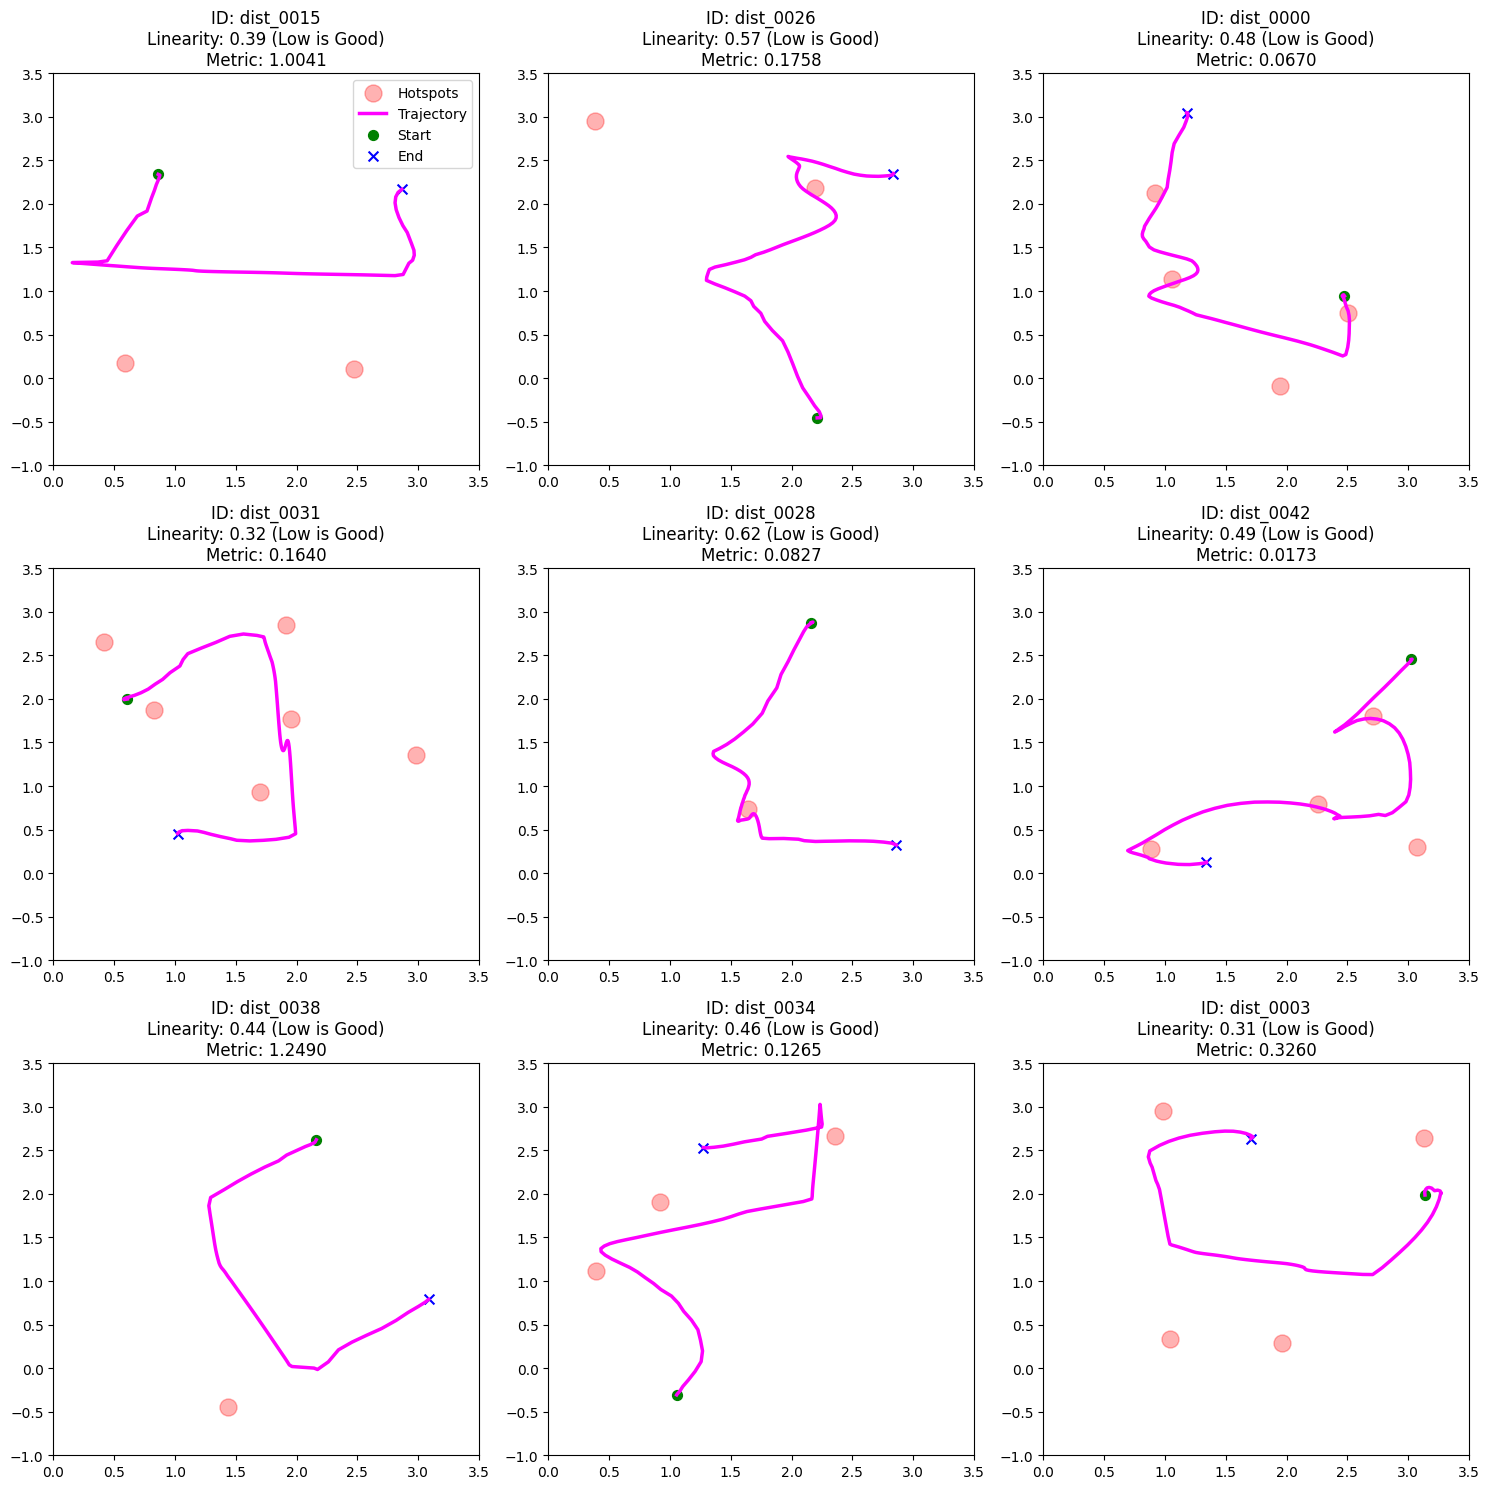

📊 正在分析前 209 / 209 条数据...


100%|███████████████████████████████████████| 209/209 [00:00<00:00, 3015.44it/s]


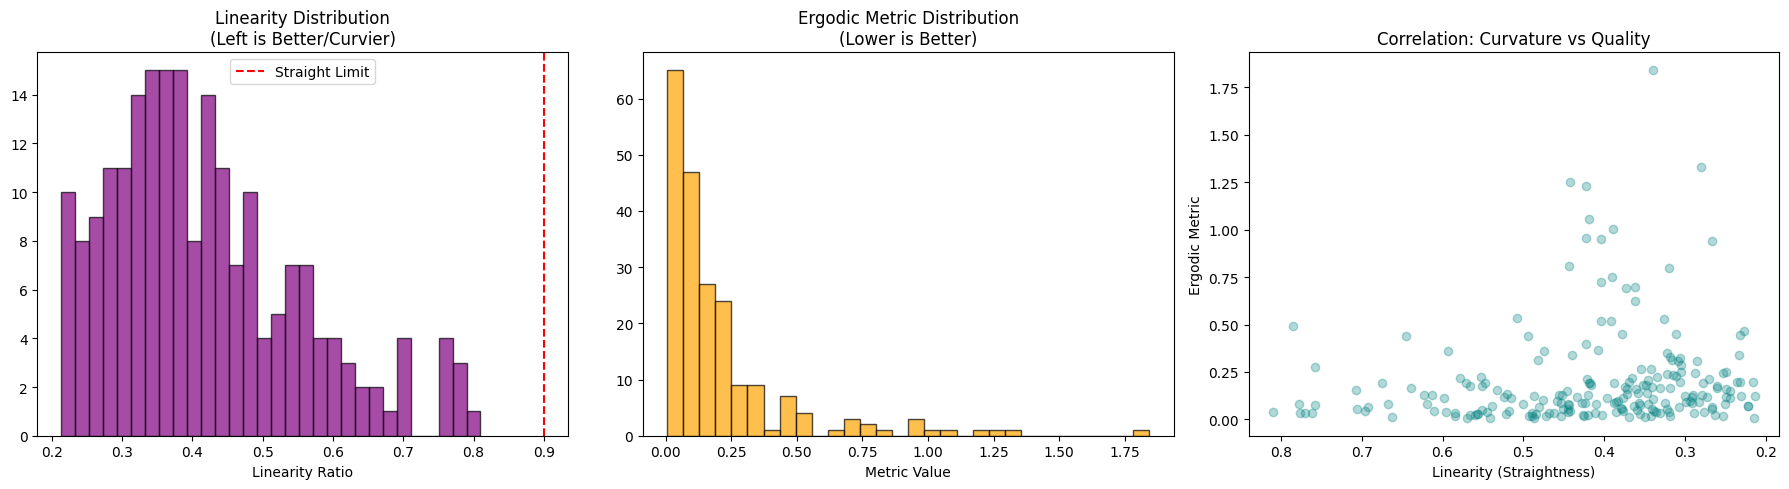


🏆 数据集质量总结:
   - 平均线性度 (Linearity): 0.4170 (越低越好)
   - 弯曲轨迹占比 (< 0.8):  99.5%
   - 平均 Ergodic Metric:   0.2058


In [26]:
# ## Cell: Verify OLD Dataset (Contrast Analysis)
import os
# 不需要重新 import 函数，直接复用内存里的

# 1. 指向旧数据路径
# 请确认这是你之前生成的、带有避障约束的旧数据集路径
DATASET_DIR = "/home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/ergodic_dataset_wild_full" 

# 2. 更新子路径
TRAJ_DIR = os.path.join(DATASET_DIR, "trajectories")
DIST_DIR = os.path.join(DATASET_DIR, "distributions")

print(f"📉 正在分析旧数据集: {DATASET_DIR}")

# 3. 执行同样的分析
# 我预测这里出来的图全是青色的直线，直方图会堆积在 1.0 附近
visualize_random_samples()
run_statistical_analysis()